In [23]:
import time
import matplotlib.pyplot as plt
import random
import numpy as np

In [ ]:
def can_R2_win(graph, weights, B):
    """
    graph: список списков смежности, graph[i] = [список соседей вершины i]
    weights: список весов вершин
    B: целевой вес для R2
    """
    n = len(weights)
    memo = {}

    def dfs(selected_mask, R2_score, R2_turn):
        key = (selected_mask, R2_score, R2_turn)
        if key in memo:
            return memo[key]

        available = []
        for v in range(n):
            if (selected_mask >> v) & 1 == 0 and all((selected_mask >> u) & 1 == 0 for u in graph[v]):
                available.append(v)

        if not available:
            memo[key] = R2_score >= B
            return memo[key]

        if R2_turn:
            for v in available:
                new_mask = selected_mask | (1 << v)
                if dfs(new_mask, R2_score + weights[v], not R2_turn):
                    memo[key] = True
                    return True
            memo[key] = False
            return False
        else:
            for v in available:
                new_mask = selected_mask | (1 << v)
                if not dfs(new_mask, R2_score, not R2_turn):
                    memo[key] = False
                    return False
            memo[key] = True
            return True

    return dfs(0, 0, True)

In [ ]:
def generate_random_graph(n, edge_prob=0.2, min_weight=1, max_weight=10, seed=None):
    """
    Генерирует случайный граф и веса вершин.
    
    n: количество вершин (зон)
    edge_prob: вероятность наличия ребра между двумя зонами
    min_weight, max_weight: диапазон весов вершин
    seed: для воспроизводимости
    """
    if seed is not None:
        random.seed(seed)
    
    graph = [[] for _ in range(n)]
    
    for i in range(n):
        for j in range(i+1, n):
            if random.random() < edge_prob:
                graph[i].append(j)
                graph[j].append(i)
    
    weights = [random.randint(min_weight, max_weight) for _ in range(n)]
    
    return graph, weights


n = 6  
graph, weights = generate_random_graph(n, edge_prob=0.3, min_weight=5, max_weight=15, seed=42)

print("Случайный граф (список смежности):", graph)
print("Вес каждой зоны:", weights)

Случайный граф (список смежности): [[2, 3, 4], [4], [0, 3, 4], [0, 2, 4, 5], [0, 1, 2, 3], [3]]
Вес каждой зоны: [13, 11, 8, 12, 14, 9]


In [26]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt

def measure_algorithm_time(algorithm, input_generator, n, n_trials=20, to_ms=False, **kwargs):
    """
    Измеряет время работы алгоритма для заданного размера входа.
    
    algorithm: функция алгоритма
    input_generator: функция генерации входных данных, принимает n и возвращает вход для алгоритма
    n: размер входа (кол-во интервалов или вершин)
    n_trials: число повторов
    to_ms: если True, возвращает время в миллисекундах
    kwargs: дополнительные аргументы для алгоритма
    """
    trial_times = []
    for _ in range(n_trials):
        data = input_generator(n)
        start = time.perf_counter()
        algorithm(*data, **kwargs)
        end = time.perf_counter()
        elapsed = (end - start) * 1000 if to_ms else (end - start)
        trial_times.append(elapsed)
    trial_times = np.array(trial_times)
    mean_t = trial_times.mean()
    std_t = trial_times.std()
    return trial_times, mean_t, std_t

In [27]:
sizes = [4, 5, 6, 7, 8, 9, 10]  
n_trials_graph = 5  
n_trials_hist = 1000 
B_factor = 2  

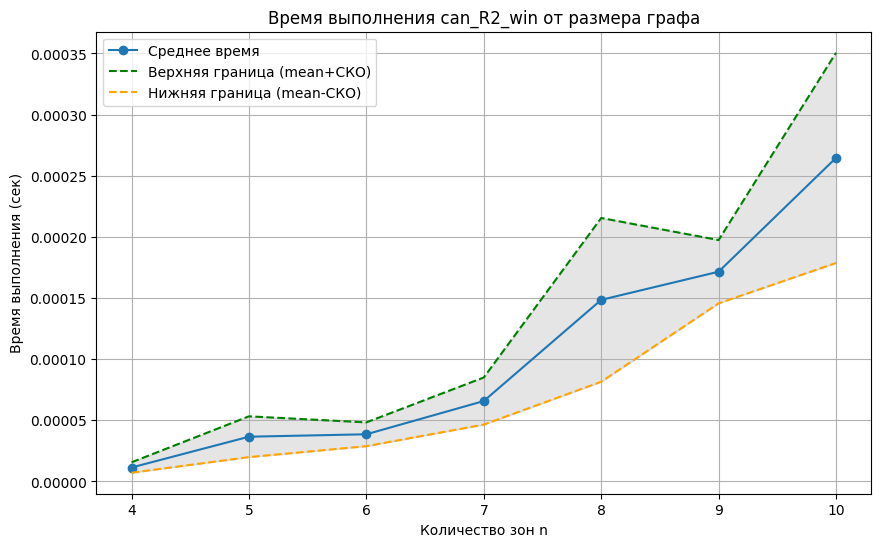

In [28]:
mean_times = []
std_times = []

for n in sizes:
    def input_gen(n):
        graph, weights = generate_random_graph(n, edge_prob=0.3, min_weight=1, max_weight=10)
        B = sum(weights) // B_factor
        return graph, weights, B
    
    _, mean_t, std_t = measure_algorithm_time(can_R2_win, input_gen, n, n_trials=n_trials_graph)
    mean_times.append(mean_t)
    std_times.append(std_t)

mean_times = np.array(mean_times)
std_times = np.array(std_times)

upper = mean_times + std_times
lower = mean_times - std_times

plt.figure(figsize=(10,6))
plt.plot(sizes, mean_times, 'o-', label='Среднее время')
plt.plot(sizes, upper, '--', color='green', label='Верхняя граница (mean+СКО)')
plt.plot(sizes, lower, '--', color='orange', label='Нижняя граница (mean-СКО)')
plt.fill_between(sizes, lower, upper, color='gray', alpha=0.2)
plt.xlabel('Количество зон n')
plt.ylabel('Время выполнения (сек)')
plt.title('Время выполнения can_R2_win от размера графа')
plt.grid(True)
plt.legend()
plt.show()

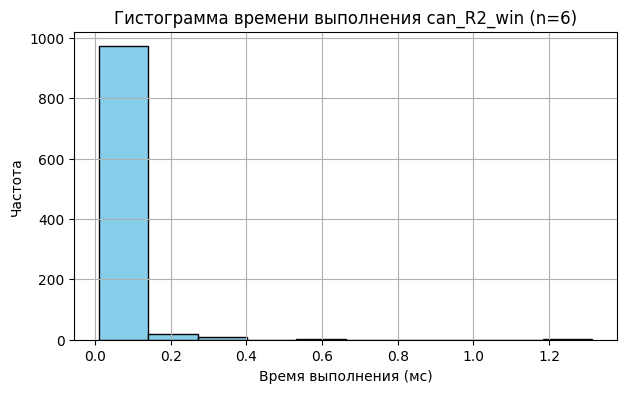

Среднее время: 0.049552 мс, Стандартное отклонение: 0.056635 мс


In [29]:
n_hist = 6  

def input_gen_hist(n):
    graph, weights = generate_random_graph(n, edge_prob=0.3, min_weight=1, max_weight=10)
    B = sum(weights) // B_factor
    return graph, weights, B

times, mean_t, std_t = measure_algorithm_time(can_R2_win, input_gen_hist, n_hist, n_trials=n_trials_hist, to_ms=True)

plt.figure(figsize=(7,4))
plt.hist(times, bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Время выполнения (мс)')
plt.ylabel('Частота')
plt.title(f'Гистограмма времени выполнения can_R2_win (n={n_hist})')
plt.grid(True)
plt.show()

print(f"Среднее время: {mean_t:.6f} мс, Стандартное отклонение: {std_t:.6f} мс")